In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
mail_data = pd.read_csv('mail_data.csv')

In [3]:
mail_data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
mail_d = mail_data.where((pd.notnull(mail_data)),'')

In [5]:
mail_d.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
mail_d.shape

(5572, 2)

In [7]:
mail_d.isnull().sum()

,0
Category,0
Message,0


In [8]:
mail_d.loc[mail_data['Category']=='spam','category',]=0
mail_d.loc[mail_data['Category']=='ham','category',]=1
#spam-0
#ham-1


In [9]:
x = mail_d['Message']
y = mail_d['category']

In [10]:
x

,Message
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will ü b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


In [11]:
y

,category
0,1.0
1,1.0
2,0.0
3,1.0
4,1.0
...,...
5567,0.0
5568,1.0
5569,1.0
5570,1.0


In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=3)


In [13]:
print(x.shape)
print(x_train.shape)
print(x_test.shape)

(5572,)
(4457,)
(1115,)


In [14]:
feature_extraction = TfidfVectorizer(min_df=1,stop_words='english',lowercase=True)
x_train_features = feature_extraction.fit_transform(x_train)
x_test_features = feature_extraction.transform(x_test)
y_train = y_train.astype('int')
y_test = y_test.astype('int')

In [15]:
print(x_train)

3075                  Don know. I did't msg him recently.
1787    Do you know why god created gap between your f...
1614                         Thnx dude. u guys out 2nite?
4304                                      Yup i'm free...
3266    44 7732584351, Do you want a New Nokia 3510i c...
                              ...                        
789     5 Free Top Polyphonic Tones call 087018728737,...
968     What do u want when i come back?.a beautiful n...
1667    Guess who spent all last night phasing in and ...
3321    Eh sorry leh... I din c ur msg. Not sad alread...
1688    Free Top ringtone -sub to weekly ringtone-get ...
Name: Message, Length: 4457, dtype: object


In [16]:
print(x_train_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34775 stored elements and shape (4457, 7431)>
  Coords	Values
  (0, 2329)	0.38783870336935383
  (0, 3811)	0.34780165336891333
  (0, 2224)	0.413103377943378
  (0, 4456)	0.4168658090846482
  (0, 5413)	0.6198254967574347
  (1, 3811)	0.17419952275504033
  (1, 3046)	0.2503712792613518
  (1, 1991)	0.33036995955537024
  (1, 2956)	0.33036995955537024
  (1, 2758)	0.3226407885943799
  (1, 1839)	0.2784903590561455
  (1, 918)	0.22871581159877646
  (1, 2746)	0.3398297002864083
  (1, 2957)	0.3398297002864083
  (1, 3325)	0.31610586766078863
  (1, 3185)	0.29694482957694585
  (1, 4080)	0.18880584110891163
  (2, 6601)	0.6056811524587518
  (2, 2404)	0.45287711070606745
  (2, 3156)	0.4107239318312698
  (2, 407)	0.509272536051008
  (3, 7414)	0.8100020912469564
  (3, 2870)	0.5864269879324768
  (4, 2870)	0.41872147309323743
  (4, 487)	0.2899118421746198
  :	:
  (4454, 2855)	0.47210665083641806
  (4454, 2246)	0.47210665083641806
  (4455, 4456)	0.24

Apply logistic Regression

In [17]:
model = LogisticRegression()

In [18]:
model.fit(x_train_features,y_train)

LogisticRegression()

In [19]:
y_pred_train = model.predict(x_train_features)
accuracy_train = accuracy_score(y_train,y_pred_train)


Accuracy of Training data

In [20]:
print('Accuracy on training data :',accuracy_train)

Accuracy on training data : 0.9676912721561588


In [21]:
x_pred_test = model.predict(x_test_features)
accuracy_test = accuracy_score(y_test,x_pred_test)


Accuracy of Testing data

In [22]:
print('Accuracy on testing data :',accuracy_test)

Accuracy on testing data : 0.9668161434977578


Confusion matrix and Classification report

In [23]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
cm = confusion_matrix(y_test,x_pred_test)
print(cm)
print(classification_report(y_test,x_pred_test))

[[118  37]
 [  0 960]]
              precision    recall  f1-score   support

           0       1.00      0.76      0.86       155
           1       0.96      1.00      0.98       960

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



Testing mail is spam or not a spam manually

In [24]:
input_mail = ["I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times"]

In [25]:
input_data_features = feature_extraction.transform(input_mail)
prediction = model.predict(input_data_features)
print(prediction)
if (prediction[0]==1):
    print('Ham mail')
else:
    print('Spam mail')


[1]
Ham mail


Apply Naive Bayes

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [27]:
# Apply Naive Bayes algorithm
model_nb = MultinomialNB()

# Train the model
model_nb.fit(x_train_features, y_train)

MultinomialNB()

In [28]:
# Make predictions on the training data
y_pred_train_nb = model_nb.predict(x_train_features)

In [29]:
# Calculate accuracy on the training data
accuracy_train_nb = accuracy_score(y_train, y_pred_train_nb)
print('Accuracy on training data (Naive Bayes):', accuracy_train_nb)

Accuracy on training data (Naive Bayes): 0.9807045097599282


In [30]:
# Make predictions on the test data
y_pred_test_nb = model_nb.predict(x_test_features)

In [31]:
# Calculate accuracy on the test data
accuracy_test_nb = accuracy_score(y_test, y_pred_test_nb)
print('Accuracy on test data (Naive Bayes):', accuracy_test_nb)

Accuracy on test data (Naive Bayes): 0.9730941704035875


In [32]:
# Confusion matrix and Classification report for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_test_nb)
print("\nConfusion Matrix (Naive Bayes):\n", cm_nb)
print("\nClassification Report (Naive Bayes):\n", classification_report(y_test, y_pred_test_nb))


Confusion Matrix (Naive Bayes):
 [[125  30]
 [  0 960]]

Classification Report (Naive Bayes):
               precision    recall  f1-score   support

           0       1.00      0.81      0.89       155
           1       0.97      1.00      0.98       960

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [33]:
# Testing a manual mail
input_mail_nb = ["I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times"]
input_data_features_nb = feature_extraction.transform(input_mail_nb)
prediction_nb = model_nb.predict(input_data_features_nb)
print("\nManual mail prediction (Naive Bayes):", prediction_nb)
if (prediction_nb[0] == 1):
    print('Ham mail')
else:
    print('Spam mail')


Manual mail prediction (Naive Bayes): [1]
Ham mail


In [34]:
input_mail = ['XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message or click here>> http://wap. xxxmobilemovieclub.com?n=QJKGIGHJJGCBL']
input_data_features = feature_extraction.transform(input_mail)
prediction = model_nb.predict(input_data_features)
print("\nManual mail prediction (Naive Bayes):", prediction)
if (prediction[0] == 1):
    print('Ham mail')
else:
    print('Spam mail')


Manual mail prediction (Naive Bayes): [0]
Spam mail


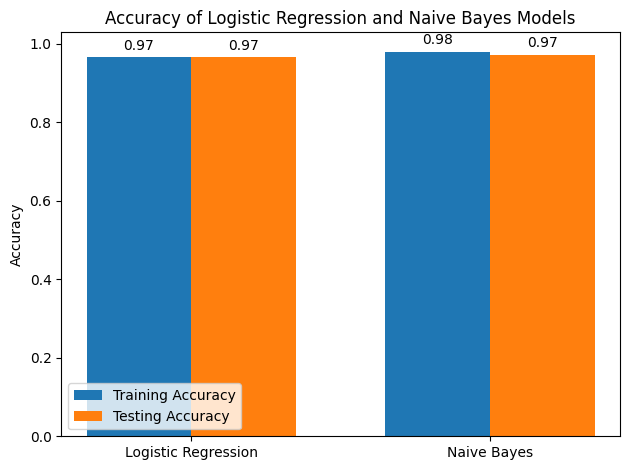

In [35]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Logistic Regression', 'Naive Bayes']
train_accuracy = [accuracy_train, accuracy_train_nb]
test_accuracy = [accuracy_test, accuracy_test_nb]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, train_accuracy, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_accuracy, width, label='Testing Accuracy')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy of Logistic Regression and Naive Bayes Models')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('%.2f' % height,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()

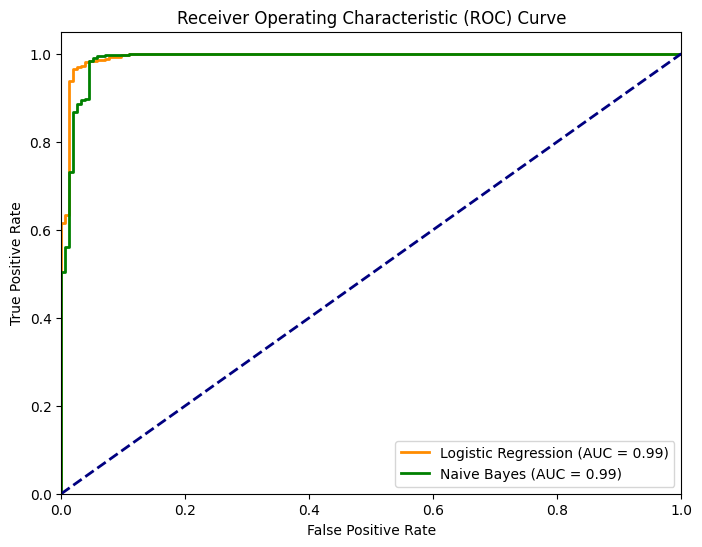

In [36]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC for Logistic Regression
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, model.predict_proba(x_test_features)[:, 1])
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Calculate ROC curve and AUC for Naive Bayes
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test, model_nb.predict_proba(x_test_features)[:, 1])
roc_auc_nb = auc(fpr_nb, tpr_nb)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label='Logistic Regression (AUC = %0.2f)' % roc_auc_lr)
plt.plot(fpr_nb, tpr_nb, color='green', lw=2, label='Naive Bayes (AUC = %0.2f)' % roc_auc_nb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()